In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [52]:
def remove_unwanted_columns(df):
    """
    Removes specific unwanted columns if they exist in the DataFrame.
    """
    unwanted = [
        'Unnamed: 0', 'nox', 'bp', 'rainfall', 'time_idx', 'Month',
        'day_of_week', 'Day_of_week', 'pm25_lag1', 'pm25_lag7', 'to_date'
    ]

    # Only drop columns that are actually present in the dataframe
    cols_to_drop = [col for col in unwanted if col in df.columns]

    return df.drop(columns=cols_to_drop)



def fix_temporal_structure(df, datetime_col='from_date', freq='h'):
    """
    Ensures the dataframe has a continuous datetime index with no gaps.
    """
    df[datetime_col] = pd.to_datetime(df[datetime_col])

    # Remove duplicates by taking the mean of entries with the same timestamp
    df = df.groupby(datetime_col).mean(numeric_only=True).reset_index()

    # Set index and fill missing hours
    df = df.set_index(datetime_col)
    df = df.asfreq(freq)

    return df



def apply_physical_bounds(df):
    """
    Clips sensor data to realistic physical limits.
    """
    # Pollutants & Wind Speed: Cannot be negative
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df[numeric_cols] = df[numeric_cols].clip(lower=0)

    # Humidity: Cannot exceed 100%
    if 'humidity' in df.columns:
        df['humidity'] = df['humidity'].clip(upper=100)

    return df



def handle_missing_values(df, max_gap=3):
    """
    Fills gaps using linear interpolation.
    'max_gap' limits interpolation so we don't 'guess' too much data.
    """
    # Interpolate small gaps linearly
    df = df.interpolate(method='linear', limit=max_gap)

    # For larger gaps, use a backfill/forward fill to catch edges
    df = df.ffill().bfill()

    return df

In [53]:
def load_and_preprocess_split(train_path, val_path, test_path):
    """
    Loads three CSVs, cleans them using the predefined pipeline,
    and returns scaled DataFrames + the fitted scaler.
    """

    # 1. Load raw data
    datasets = {
        'train': pd.read_csv(train_path),
        'val': pd.read_csv(val_path),
        'test': pd.read_csv(test_path)
    }

    processed_dfs = {}

    for name, df in datasets.items():
        # Apply the pipeline we built earlier
        # Note: 'city' and 'to_date' are usually dropped for modeling
        df_clean = (df.pipe(remove_unwanted_columns)  # 1. Strip junk first
                      .pipe(fix_temporal_structure)    # 2. Fix time index
                      .pipe(apply_physical_bounds)    # 3. Clip sensor errors
                      .pipe(handle_missing_values))    # 4. Fill NaNs


        processed_dfs[name] = df_clean

    # 2. Feature Scaling (Standardization)
    # We fit ONLY on train to prevent data leakage
    scaler = MinMaxScaler()
    feature_cols = processed_dfs['train'].columns

    # Fit on train
    scaler.fit(processed_dfs['train'][feature_cols])

    # Transform all sets
    for name in processed_dfs:
        scaled_values = scaler.transform(processed_dfs[name][feature_cols])
        processed_dfs[name] = pd.DataFrame(
            scaled_values,
            columns=feature_cols,
            index=processed_dfs[name].index
        )

    return processed_dfs['train'], processed_dfs['val'], processed_dfs['test'], scaler

In [54]:
train_data, val_data, test_data, fitted_scaler = load_and_preprocess_split('Train_data.csv', 'Validation_data.csv', 'Test_data.csv')

In [55]:
train_data.head(2)

,pm25,pm10,no,nh3,no2,so2,co,ozone,wind_speed,air_temp,humidity
from_date,,,,,,,,,,,
2017-01-01 00:00:00,0.247949,0.320867,0.160433,0.311409,0.232873,0.206213,0.160895,0.119595,0.016364,0.181511,0.873987
2017-01-01 01:00:00,0.258709,0.344419,0.171318,0.309085,0.228160,0.189554,0.182749,0.115936,0.017504,0.169319,0.880803


In [56]:
val_data.head(2)

,pm25,pm10,no,nh3,no2,so2,co,ozone,wind_speed,air_temp,humidity
from_date,,,,,,,,,,,
2023-01-01 00:00:00,0.191747,0.226563,0.148611,0.220066,0.149775,0.098529,0.116798,0.032616,0.014563,0.175851,0.874877
2023-01-01 01:00:00,0.185043,0.218535,0.114174,0.218260,0.133553,0.091319,0.102693,0.036589,0.012512,0.170726,0.878298


In [57]:
test_data.head(2)

,pm25,pm10,no,nh3,no2,so2,co,ozone,wind_speed,air_temp,humidity
from_date,,,,,,,,,,,
2023-03-01 00:00:00,0.081741,0.232646,0.266218,0.168774,0.199797,0.114118,0.125023,0.031284,0.02508,0.347751,0.559211
2023-03-01 01:00:00,0.090282,0.258060,0.213401,0.183553,0.180402,0.108866,0.113532,0.036754,0.02163,0.351402,0.534649


In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [59]:
print("Train columns:")
print(train_data.columns.tolist())

Train columns:
['pm25', 'pm10', 'no', 'nh3', 'no2', 'so2', 'co', 'ozone', 'wind_speed', 'air_temp', 'humidity']


# Method 1: Predict PM2.5

In [60]:
target_col   = 'pm25'
feature_cols = ['pm25', 'pm10', 'no', 'nh3', 'no2','so2', 'co', 'ozone', 'wind_speed', 'air_temp', 'humidity']

In [61]:
# FIX 1: Slice the 10 feature columns FIRST, then fit the scaler on them.
# Using fitted_scaler here would cause a column-count mismatch on inverse transform.
train_df = train_data[feature_cols].copy()
val_df   = val_data[feature_cols].copy()
test_df  = test_data[feature_cols].copy()

This creates input windows of past observations and predicts the next 24 PM2.5 values (24-hour horizon).

In [62]:
# FIX 2: horizon=24 so y contains the next 24 hours, matching Dense(24) output.
def create_sequences(df, target_col, lookback=168, horizon=24):
    X, y = [], []
    values    = df.values
    target_idx = df.columns.get_loc(target_col)

    for i in range(lookback, len(df) - horizon + 1):
        X.append(values[i - lookback : i])            # shape: (168, 10)
        y.append(values[i : i + horizon, target_idx]) # shape: (24,)

    return np.array(X), np.array(y)

In [63]:
lookback = 168   # past 7 days
horizon  = 24    # predict next 24 hours

X_train, y_train = create_sequences(train_df, target_col, lookback, horizon)
X_val,   y_val   = create_sequences(val_df,   target_col, lookback, horizon)
X_test,  y_test  = create_sequences(test_df,  target_col, lookback, horizon)

print("X_train:", X_train.shape)  # (samples, 168, 10)
print("y_train:", y_train.shape)  # (samples, 24)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)

X_train: (52393, 168, 11)
y_train: (52393, 24)
X_val:   (1225, 168, 11)
X_test:  (553, 168, 11)


In [64]:
from tensorflow.keras.optimizers import Adam
n_features = X_train.shape[2]

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(lookback, n_features)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(horizon)   # outputs 24 values
])

model.compile(optimizer=Adam(learning_rate=0.0001), loss='mse', metrics=['mae'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 168, 64)        │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 168, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 24)             │           408 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,808 (128.16 KB)

 Trainable params: 32,808 (128.16 KB)

 Non-trainable params: 0 (0.00 B)

In [65]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 0.0105 - mae: 0.0639 - val_loss: 0.0059 - val_mae: 0.0583
Epoch 2/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 0.0044 - mae: 0.0435 - val_loss: 0.0057 - val_mae: 0.0578
Epoch 3/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 0.0040 - mae: 0.0411 - val_loss: 0.0057 - val_mae: 0.0581
Epoch 4/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 0.0037 - mae: 0.0391 - val_loss: 0.0057 - val_mae: 0.0574
Epoch 5/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 0.0035 - mae: 0.0376 - val_loss: 0.0047 - val_mae: 0.0511
Epoch 6/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 0.0033 - mae: 0.0367 - val_loss: 0.0047 - val_mae: 0.0511
Epoch 7/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 0.0032 - mae: 0.0362 - val_loss: 0.0043 - val_mae: 0.0486
Epoch 8/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 0.0031 - mae: 0.0357 - val_loss: 0.0043 - val_mae: 0.0479
Epoch 9/50
1638/1638 ━━━

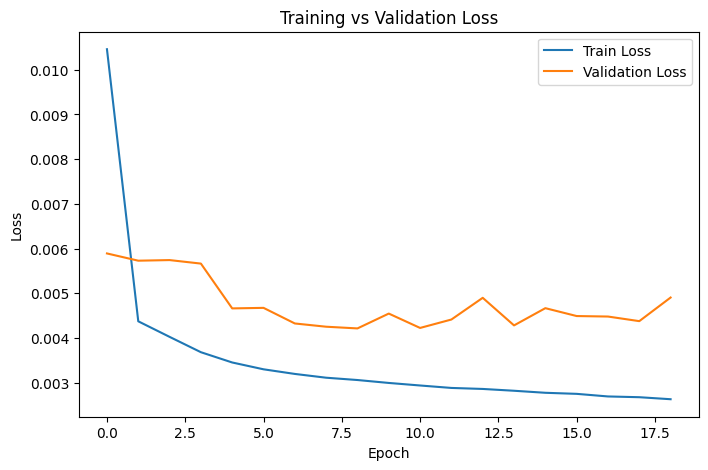

In [66]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

In [67]:
# FIX 3: No .flatten() — model.predict returns (samples, 24). Keep 2D shape.
y_pred_scaled = model.predict(X_test)   # shape: (samples, 24)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


In [68]:
def inverse_transform_target_only(scaler, y_scaled, feature_columns, target_col):
    """
    Inverse transforms only the target column.
    Works for both 1D (samples,) and 2D (samples, horizon) y_scaled.
    """
    y_scaled   = np.array(y_scaled)
    target_idx = list(feature_columns).index(target_col)
    n_features = len(feature_columns)

    # Flatten to 1D, inverse transform, then reshape back
    original_shape = y_scaled.shape
    y_flat = y_scaled.flatten()

    temp = np.zeros((len(y_flat), n_features))
    temp[:, target_idx] = y_flat
    inv = scaler.inverse_transform(temp)[:, target_idx]

    return inv.reshape(original_shape)

In [69]:
# Use train_data.columns, not feature_cols
all_cols = train_data.columns.tolist()

y_test_actual = inverse_transform_target_only(fitted_scaler, y_test,        all_cols, target_col)
y_pred_actual = inverse_transform_target_only(fitted_scaler, y_pred_scaled,  all_cols, target_col)
# Both are shape (samples, 24) — real PM2.5 values
print("y_test_actual shape:", y_test_actual.shape)
print("y_pred_actual shape:", y_pred_actual.shape)

y_test_actual shape: (553, 24)
y_pred_actual shape: (553, 24)


In [70]:
y_pred_actual

array([[136.14565187, 142.4846297 , 145.04042019, ..., 105.32080566,
        113.27701639, 123.46535447],
       [155.38676249, 158.39279573, 158.42639838, ..., 123.61661046,
        132.22858272, 140.37757117],
       [172.14155411, 171.33468767, 168.89608468, ..., 141.7532024 ,
        150.38944814, 155.9822684 ],
       ...,
       [ 45.84254749,  58.73318248,  67.51839282, ...,  56.46382026,
         54.60601494,  62.09116853],
       [ 47.11907987,  57.99977226,  65.94998386, ...,  54.15148215,
         52.50929592,  60.35915282],
       [ 49.1666004 ,  57.85456576,  65.07102721, ...,  52.58439514,
         51.35657652,  59.48159366]])

In [71]:
# FIX 4: Removed duplicate metrics cell. Flatten both arrays for overall metrics.
mae  = mean_absolute_error(y_test_actual.flatten(), y_pred_actual.flatten())
rmse = np.sqrt(mean_squared_error(y_test_actual.flatten(), y_pred_actual.flatten()))
r2   = r2_score(y_test_actual.flatten(), y_pred_actual.flatten())

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

MAE  : 27.1446
RMSE : 34.5935
R²   : 0.1655


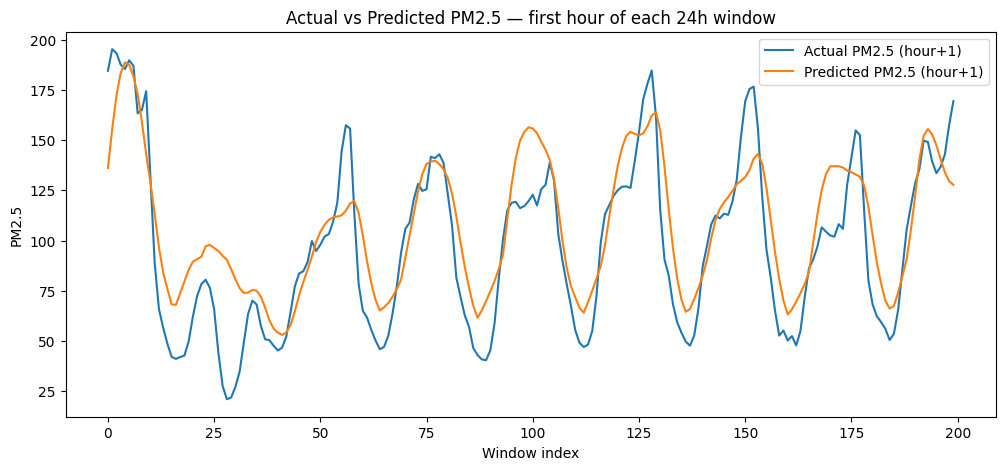

In [72]:
# Plot the first 200 predictions (hour 1 of each 24-hour window)
plt.figure(figsize=(12, 5))
plt.plot(y_test_actual[:200, 0], label='Actual PM2.5 (hour+1)')
plt.plot(y_pred_actual[:200, 0], label='Predicted PM2.5 (hour+1)')
plt.xlabel('Window index')
plt.ylabel('PM2.5')
plt.title('Actual vs Predicted PM2.5 — first hour of each 24h window')
plt.legend()
plt.show()

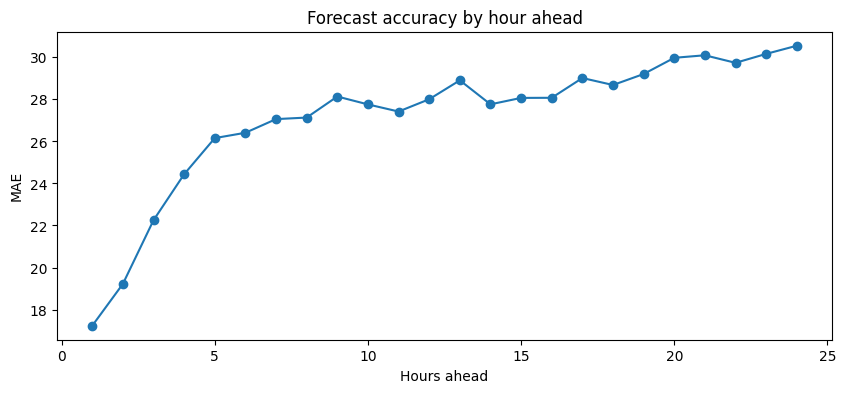

In [73]:
# Per-hour MAE across the 24-hour horizon
per_hour_mae = [mean_absolute_error(y_test_actual[:, h], y_pred_actual[:, h]) for h in range(24)]

plt.figure(figsize=(10, 4))
plt.plot(range(1, 25), per_hour_mae, marker='o')
plt.xlabel('Hours ahead')
plt.ylabel('MAE')
plt.title('Forecast accuracy by hour ahead')
plt.show()

Text(0.5, 1.0, 'R² by hour ahead')

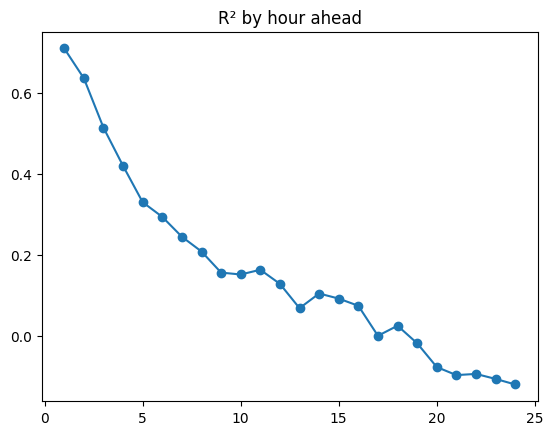

In [74]:
per_hour_r2 = [r2_score(y_test_actual[:, h], y_pred_actual[:, h]) for h in range(24)]
plt.plot(range(1, 25), per_hour_r2, marker='o')
plt.title('R² by hour ahead')

# Method 2: Predict NO2

In [75]:
no2_target_col   = 'no2'
no2_feature_cols = ['pm25', 'pm10', 'no', 'nh3', 'no2','so2', 'co', 'ozone', 'wind_speed', 'air_temp', 'humidity']

In [76]:
no2_train_df = train_data[no2_feature_cols].copy()
no2_val_df   = val_data[no2_feature_cols].copy()
no2_test_df  = test_data[no2_feature_cols].copy()

This creates input windows of past observations and predicts the next 24 NO2 values (24-hour horizon).

In [77]:
# horizon=24 so y contains the next 24 hours, matching Dense(24) output.
def create_sequences_no2(df, target_col, lookback=168, horizon=24):
    X, y = [], []
    values     = df.values
    target_idx = df.columns.get_loc(target_col)

    for i in range(lookback, len(df) - horizon + 1):
        X.append(values[i - lookback : i])            # shape: (168, 11)
        y.append(values[i : i + horizon, target_idx]) # shape: (24,)

    return np.array(X), np.array(y)

In [78]:
no2_lookback = 168   # past 7 days
no2_horizon  = 24    # predict next 24 hours

X_train_no2, y_train_no2 = create_sequences_no2(no2_train_df, no2_target_col, no2_lookback, no2_horizon)
X_val_no2,   y_val_no2   = create_sequences_no2(no2_val_df,   no2_target_col, no2_lookback, no2_horizon)
X_test_no2,  y_test_no2  = create_sequences_no2(no2_test_df,  no2_target_col, no2_lookback, no2_horizon)

print('X_train_no2:', X_train_no2.shape)
print('y_train_no2:', y_train_no2.shape)
print('X_val_no2:  ', X_val_no2.shape)
print('X_test_no2: ', X_test_no2.shape)

X_train_no2: (52393, 168, 11)
y_train_no2: (52393, 24)
X_val_no2:   (1225, 168, 11)
X_test_no2:  (553, 168, 11)


In [79]:
from tensorflow.keras.optimizers import Adam

no2_n_features = X_train_no2.shape[2]

model_no2 = Sequential([
    LSTM(64, return_sequences=True, input_shape=(no2_lookback, no2_n_features)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(no2_horizon)   # outputs 24 values
])

model_no2.compile(optimizer=Adam(learning_rate=0.0001), loss='mse', metrics=['mae'])
model_no2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 168, 64)        │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 168, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 24)             │           408 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,808 (128.16 KB)

 Trainable params: 32,808 (128.16 KB)

 Non-trainable params: 0 (0.00 B)

In [80]:
early_stop_no2 = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history_no2 = model_no2.fit(
    X_train_no2, y_train_no2,
    validation_data=(X_val_no2, y_val_no2),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop_no2],
    verbose=1
)

Epoch 1/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 26s 15ms/step - loss: 0.0149 - mae: 0.0861 - val_loss: 0.0059 - val_mae: 0.0630
Epoch 2/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 0.0072 - mae: 0.0630 - val_loss: 0.0053 - val_mae: 0.0596
Epoch 3/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 0.0063 - mae: 0.0583 - val_loss: 0.0049 - val_mae: 0.0571
Epoch 4/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 0.0057 - mae: 0.0551 - val_loss: 0.0044 - val_mae: 0.0538
Epoch 5/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 0.0053 - mae: 0.0529 - val_loss: 0.0041 - val_mae: 0.0520
Epoch 6/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 0.0050 - mae: 0.0510 - val_loss: 0.0037 - val_mae: 0.0485
Epoch 7/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 0.0047 - mae: 0.0494 - val_loss: 0.0035 - val_mae: 0.0469
Epoch 8/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 0.0045 - mae: 0.0483 - val_loss: 0.0032 - val_mae: 0.0450
Epoch 9/50
1638/1638 ━━━

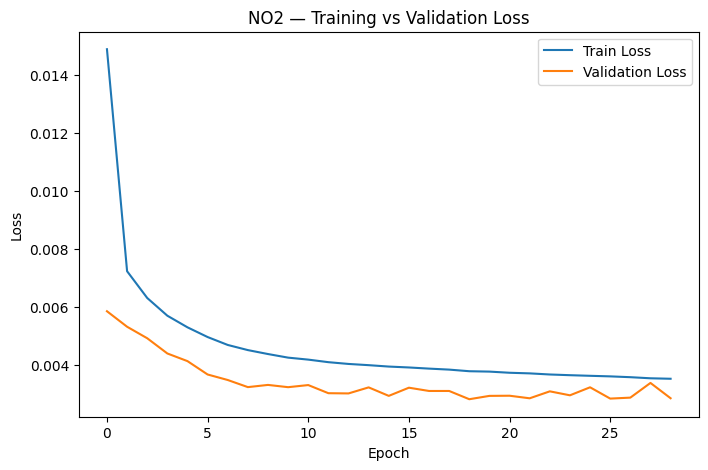

In [81]:
plt.figure(figsize=(8, 5))
plt.plot(history_no2.history['loss'],     label='Train Loss')
plt.plot(history_no2.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('NO2 — Training vs Validation Loss')
plt.legend()
plt.show()

In [82]:
# model.predict returns (samples, 24). Keep 2D shape.
y_pred_scaled_no2 = model_no2.predict(X_test_no2)   # shape: (samples, 24)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


In [83]:
def inverse_transform_target_only_no2(scaler, y_scaled, feature_columns, target_col):
    """
    Inverse transforms only the target column.
    Works for both 1D (samples,) and 2D (samples, horizon) y_scaled.
    """
    y_scaled   = np.array(y_scaled)
    target_idx = list(feature_columns).index(target_col)
    n_features = len(feature_columns)

    original_shape = y_scaled.shape
    y_flat = y_scaled.flatten()

    temp = np.zeros((len(y_flat), n_features))
    temp[:, target_idx] = y_flat
    inv = scaler.inverse_transform(temp)[:, target_idx]

    return inv.reshape(original_shape)

In [84]:
no2_all_cols = train_data.columns.tolist()

y_test_actual_no2 = inverse_transform_target_only_no2(fitted_scaler, y_test_no2,        no2_all_cols, no2_target_col)
y_pred_actual_no2 = inverse_transform_target_only_no2(fitted_scaler, y_pred_scaled_no2, no2_all_cols, no2_target_col)

print('y_test_actual_no2 shape:', y_test_actual_no2.shape)
print('y_pred_actual_no2 shape:', y_pred_actual_no2.shape)

y_test_actual_no2 shape: (553, 24)
y_pred_actual_no2 shape: (553, 24)


In [85]:
mae_no2  = mean_absolute_error(y_test_actual_no2.flatten(), y_pred_actual_no2.flatten())
rmse_no2 = np.sqrt(mean_squared_error(y_test_actual_no2.flatten(), y_pred_actual_no2.flatten()))
r2_no2   = r2_score(y_test_actual_no2.flatten(), y_pred_actual_no2.flatten())

print(f'MAE  : {mae_no2:.4f}')
print(f'RMSE : {rmse_no2:.4f}')
print(f'R²   : {r2_no2:.4f}')

MAE  : 6.6937
RMSE : 8.6268
R²   : 0.4514


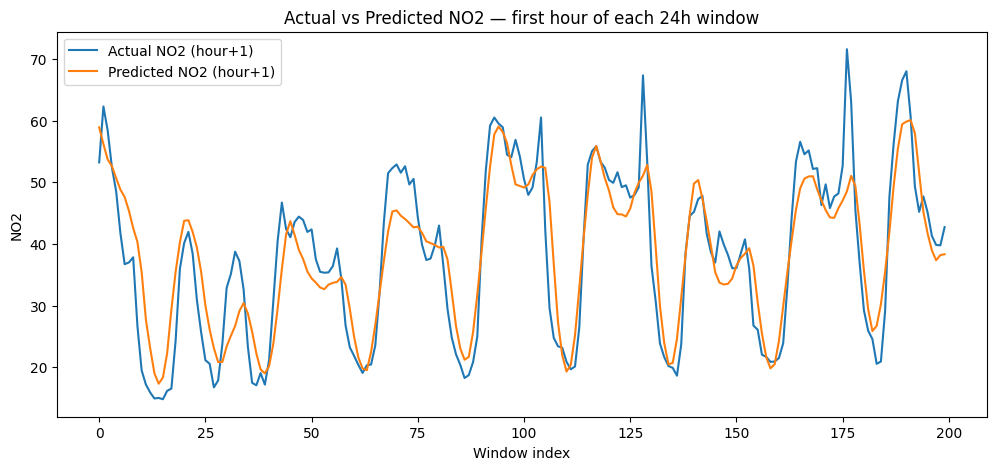

In [86]:
plt.figure(figsize=(12, 5))
plt.plot(y_test_actual_no2[:200, 0], label='Actual NO2 (hour+1)')
plt.plot(y_pred_actual_no2[:200, 0], label='Predicted NO2 (hour+1)')
plt.xlabel('Window index')
plt.ylabel('NO2')
plt.title('Actual vs Predicted NO2 — first hour of each 24h window')
plt.legend()
plt.show()

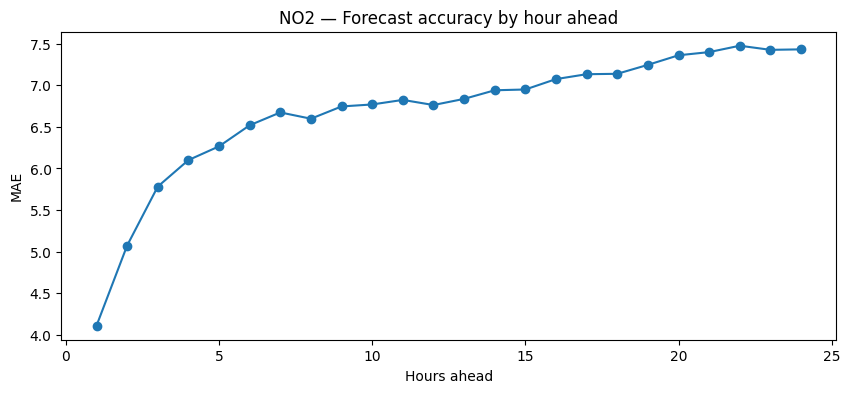

In [87]:
per_hour_mae_no2 = [mean_absolute_error(y_test_actual_no2[:, h], y_pred_actual_no2[:, h]) for h in range(24)]

plt.figure(figsize=(10, 4))
plt.plot(range(1, 25), per_hour_mae_no2, marker='o')
plt.xlabel('Hours ahead')
plt.ylabel('MAE')
plt.title('NO2 — Forecast accuracy by hour ahead')
plt.show()

# Method 3: Predict CO

In [88]:
co_target_col   = 'co'
co_feature_cols = ['pm25', 'pm10', 'no', 'nh3', 'no2','so2', 'co', 'ozone', 'wind_speed', 'air_temp', 'humidity']

In [89]:
co_train_df = train_data[co_feature_cols].copy()
co_val_df   = val_data[co_feature_cols].copy()
co_test_df  = test_data[co_feature_cols].copy()

This creates input windows of past observations and predicts the next 24 CO values (24-hour horizon).

In [90]:
def create_sequences_co(df, target_col, lookback=168, horizon=24):
    X, y = [], []
    values     = df.values
    target_idx = df.columns.get_loc(target_col)

    for i in range(lookback, len(df) - horizon + 1):
        X.append(values[i - lookback : i])            # shape: (168, 11)
        y.append(values[i : i + horizon, target_idx]) # shape: (24,)

    return np.array(X), np.array(y)

In [91]:
co_lookback = 168   # past 7 days
co_horizon  = 24    # predict next 24 hours

X_train_co, y_train_co = create_sequences_co(co_train_df, co_target_col, co_lookback, co_horizon)
X_val_co,   y_val_co   = create_sequences_co(co_val_df,   co_target_col, co_lookback, co_horizon)
X_test_co,  y_test_co  = create_sequences_co(co_test_df,  co_target_col, co_lookback, co_horizon)

print('X_train_co:', X_train_co.shape)
print('y_train_co:', y_train_co.shape)
print('X_val_co:  ', X_val_co.shape)
print('X_test_co: ', X_test_co.shape)

X_train_co: (52393, 168, 11)
y_train_co: (52393, 24)
X_val_co:   (1225, 168, 11)
X_test_co:  (553, 168, 11)


In [92]:
from tensorflow.keras.optimizers import Adam

co_n_features = X_train_co.shape[2]

model_co = Sequential([
    LSTM(64, return_sequences=True, input_shape=(co_lookback, co_n_features)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(co_horizon)   # outputs 24 values
])

model_co.compile(optimizer=Adam(learning_rate=0.0001), loss='mse', metrics=['mae'])
model_co.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                  │ (None, 168, 64)        │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 168, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 24)             │           408 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,808 (128.16 KB)

 Trainable params: 32,808 (128.16 KB)

 Non-trainable params: 0 (0.00 B)

In [93]:
early_stop_co = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history_co = model_co.fit(
    X_train_co, y_train_co,
    validation_data=(X_val_co, y_val_co),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop_co],
    verbose=1
)

Epoch 1/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 0.0041 - mae: 0.0429 - val_loss: 0.0021 - val_mae: 0.0359
Epoch 2/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 0.0025 - mae: 0.0335 - val_loss: 0.0017 - val_mae: 0.0310
Epoch 3/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 0.0021 - mae: 0.0304 - val_loss: 0.0015 - val_mae: 0.0294
Epoch 4/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 0.0020 - mae: 0.0293 - val_loss: 0.0015 - val_mae: 0.0301
Epoch 5/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 0.0019 - mae: 0.0285 - val_loss: 0.0014 - val_mae: 0.0287
Epoch 6/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 0.0018 - mae: 0.0278 - val_loss: 0.0014 - val_mae: 0.0282
Epoch 7/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 0.0018 - mae: 0.0274 - val_loss: 0.0013 - val_mae: 0.0269
Epoch 8/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 0.0017 - mae: 0.0269 - val_loss: 0.0013 - val_mae: 0.0277
Epoch 9/50
1638/1638 ━━━

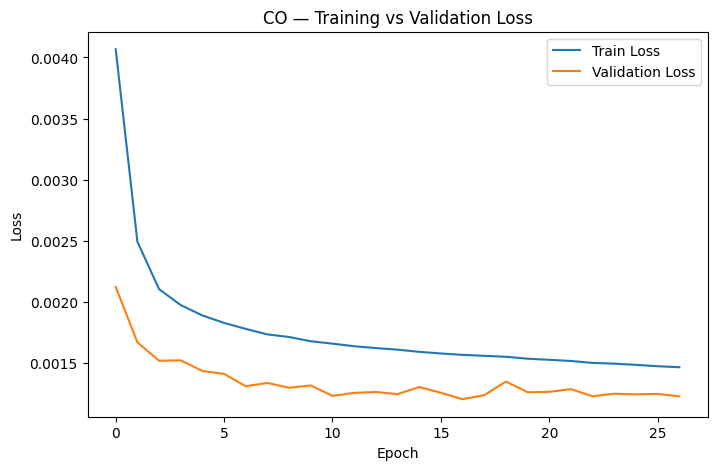

In [94]:
plt.figure(figsize=(8, 5))
plt.plot(history_co.history['loss'],     label='Train Loss')
plt.plot(history_co.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CO — Training vs Validation Loss')
plt.legend()
plt.show()

In [95]:
y_pred_scaled_co = model_co.predict(X_test_co)   # shape: (samples, 24)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


In [96]:
def inverse_transform_co(scaler, y_scaled, feature_columns, target_col):
    y_scaled   = np.array(y_scaled)
    target_idx = list(feature_columns).index(target_col)
    n_feat     = len(feature_columns)
    original_shape = y_scaled.shape
    y_flat = y_scaled.flatten()
    temp = np.zeros((len(y_flat), n_feat))
    temp[:, target_idx] = y_flat
    inv = scaler.inverse_transform(temp)[:, target_idx]
    return inv.reshape(original_shape)

In [97]:
co_all_cols = train_data.columns.tolist()

y_test_actual_co = inverse_transform_co(fitted_scaler, y_test_co,          co_all_cols, co_target_col)
y_pred_actual_co = inverse_transform_co(fitted_scaler, y_pred_scaled_co,   co_all_cols, co_target_col)

print('y_test_actual_co shape:', y_test_actual_co.shape)
print('y_pred_actual_co shape:', y_pred_actual_co.shape)

y_test_actual_co shape: (553, 24)
y_pred_actual_co shape: (553, 24)


In [98]:
mae_co  = mean_absolute_error(y_test_actual_co.flatten(), y_pred_actual_co.flatten())
rmse_co = np.sqrt(mean_squared_error(y_test_actual_co.flatten(), y_pred_actual_co.flatten()))
r2_co   = r2_score(y_test_actual_co.flatten(), y_pred_actual_co.flatten())

print(f'MAE  : {mae_co:.4f}')
print(f'RMSE : {rmse_co:.4f}')
print(f'R²   : {r2_co:.4f}')

MAE  : 0.2543
RMSE : 0.3398
R²   : 0.3063


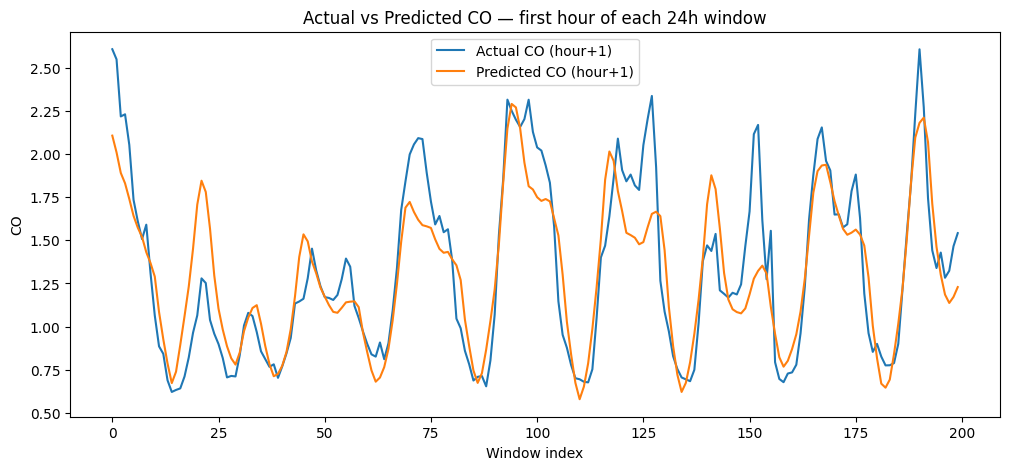

In [99]:
plt.figure(figsize=(12, 5))
plt.plot(y_test_actual_co[:200, 0], label='Actual CO (hour+1)')
plt.plot(y_pred_actual_co[:200, 0], label='Predicted CO (hour+1)')
plt.xlabel('Window index')
plt.ylabel('CO')
plt.title('Actual vs Predicted CO — first hour of each 24h window')
plt.legend()
plt.show()

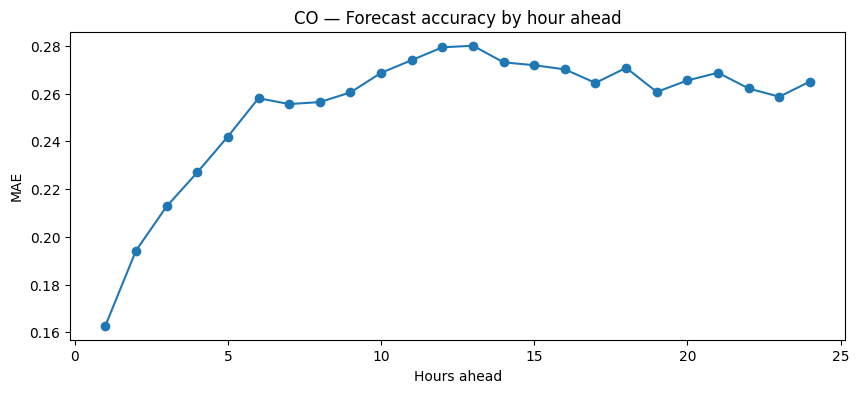

In [100]:
per_hour_mae_co = [mean_absolute_error(y_test_actual_co[:, h], y_pred_actual_co[:, h]) for h in range(24)]

plt.figure(figsize=(10, 4))
plt.plot(range(1, 25), per_hour_mae_co, marker='o')
plt.xlabel('Hours ahead')
plt.ylabel('MAE')
plt.title('CO — Forecast accuracy by hour ahead')
plt.show()

Text(0.5, 1.0, 'CO — R² by hour ahead')

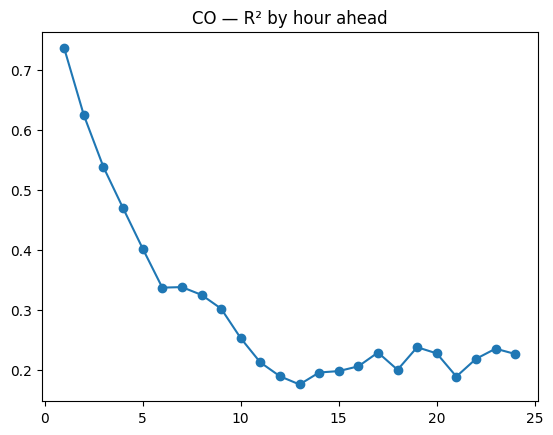

In [101]:
per_hour_r2_co = [r2_score(y_test_actual_co[:, h], y_pred_actual_co[:, h]) for h in range(24)]
plt.plot(range(1, 25), per_hour_r2_co, marker='o')
plt.title('CO — R² by hour ahead')

# Method 4: Predict Ozone

In [102]:
ozone_target_col   = 'ozone'
ozone_feature_cols = ['pm25', 'pm10', 'no', 'nh3', 'no2','so2', 'co', 'ozone', 'wind_speed', 'air_temp', 'humidity']

In [103]:
ozone_train_df = train_data[ozone_feature_cols].copy()
ozone_val_df   = val_data[ozone_feature_cols].copy()
ozone_test_df  = test_data[ozone_feature_cols].copy()

This creates input windows of past observations and predicts the next 24 Ozone values (24-hour horizon).

In [104]:
def create_sequences_ozone(df, target_col, lookback=168, horizon=24):
    X, y = [], []
    values     = df.values
    target_idx = df.columns.get_loc(target_col)

    for i in range(lookback, len(df) - horizon + 1):
        X.append(values[i - lookback : i])            # shape: (168, 11)
        y.append(values[i : i + horizon, target_idx]) # shape: (24,)

    return np.array(X), np.array(y)

In [105]:
ozone_lookback = 168   # past 7 days
ozone_horizon  = 24    # predict next 24 hours

X_train_ozone, y_train_ozone = create_sequences_ozone(ozone_train_df, ozone_target_col, ozone_lookback, ozone_horizon)
X_val_ozone,   y_val_ozone   = create_sequences_ozone(ozone_val_df,   ozone_target_col, ozone_lookback, ozone_horizon)
X_test_ozone,  y_test_ozone  = create_sequences_ozone(ozone_test_df,  ozone_target_col, ozone_lookback, ozone_horizon)

print('X_train_ozone:', X_train_ozone.shape)
print('y_train_ozone:', y_train_ozone.shape)
print('X_val_ozone:  ', X_val_ozone.shape)
print('X_test_ozone: ', X_test_ozone.shape)

X_train_ozone: (52393, 168, 11)
y_train_ozone: (52393, 24)
X_val_ozone:   (1225, 168, 11)
X_test_ozone:  (553, 168, 11)


In [106]:
from tensorflow.keras.optimizers import Adam

ozone_n_features = X_train_ozone.shape[2]

model_ozone = Sequential([
    LSTM(64, return_sequences=True, input_shape=(ozone_lookback, ozone_n_features)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(ozone_horizon)   # outputs 24 values
])

model_ozone.compile(optimizer=Adam(learning_rate=0.0001), loss='mse', metrics=['mae'])
model_ozone.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 168, 64)        │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 168, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 24)             │           408 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,808 (128.16 KB)

 Trainable params: 32,808 (128.16 KB)

 Non-trainable params: 0 (0.00 B)

In [107]:
early_stop_ozone = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history_ozone = model_ozone.fit(
    X_train_ozone, y_train_ozone,
    validation_data=(X_val_ozone, y_val_ozone),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop_ozone],
    verbose=1
)

Epoch 1/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 0.0240 - mae: 0.1099 - val_loss: 0.0074 - val_mae: 0.0691
Epoch 2/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 0.0096 - mae: 0.0732 - val_loss: 0.0050 - val_mae: 0.0557
Epoch 3/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 0.0078 - mae: 0.0652 - val_loss: 0.0041 - val_mae: 0.0498
Epoch 4/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 0.0070 - mae: 0.0612 - val_loss: 0.0037 - val_mae: 0.0473
Epoch 5/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 0.0066 - mae: 0.0591 - val_loss: 0.0035 - val_mae: 0.0458
Epoch 6/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 0.0063 - mae: 0.0578 - val_loss: 0.0034 - val_mae: 0.0448
Epoch 7/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 0.0061 - mae: 0.0569 - val_loss: 0.0033 - val_mae: 0.0443
Epoch 8/50
1638/1638 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - loss: 0.0060 - mae: 0.0563 - val_loss: 0.0032 - val_mae: 0.0440
Epoch 9/50
1638/1638 ━━━

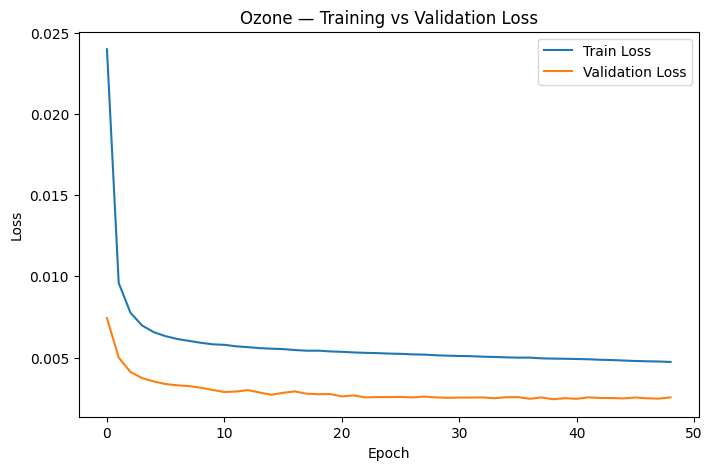

In [108]:
plt.figure(figsize=(8, 5))
plt.plot(history_ozone.history['loss'],     label='Train Loss')
plt.plot(history_ozone.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Ozone — Training vs Validation Loss')
plt.legend()
plt.show()

In [109]:
y_pred_scaled_ozone = model_ozone.predict(X_test_ozone)   # shape: (samples, 24)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


In [110]:
def inverse_transform_ozone(scaler, y_scaled, feature_columns, target_col):
    y_scaled   = np.array(y_scaled)
    target_idx = list(feature_columns).index(target_col)
    n_feat     = len(feature_columns)
    original_shape = y_scaled.shape
    y_flat = y_scaled.flatten()
    temp = np.zeros((len(y_flat), n_feat))
    temp[:, target_idx] = y_flat
    inv = scaler.inverse_transform(temp)[:, target_idx]
    return inv.reshape(original_shape)

In [111]:
ozone_all_cols = train_data.columns.tolist()

y_test_actual_ozone = inverse_transform_ozone(fitted_scaler, y_test_ozone,          ozone_all_cols, ozone_target_col)
y_pred_actual_ozone = inverse_transform_ozone(fitted_scaler, y_pred_scaled_ozone,   ozone_all_cols, ozone_target_col)

print('y_test_actual_ozone shape:', y_test_actual_ozone.shape)
print('y_pred_actual_ozone shape:', y_pred_actual_ozone.shape)

y_test_actual_ozone shape: (553, 24)
y_pred_actual_ozone shape: (553, 24)


In [112]:
mae_ozone  = mean_absolute_error(y_test_actual_ozone.flatten(), y_pred_actual_ozone.flatten())
rmse_ozone = np.sqrt(mean_squared_error(y_test_actual_ozone.flatten(), y_pred_actual_ozone.flatten()))
r2_ozone   = r2_score(y_test_actual_ozone.flatten(), y_pred_actual_ozone.flatten())

print(f'MAE  : {mae_ozone:.4f}')
print(f'RMSE : {rmse_ozone:.4f}')
print(f'R²   : {r2_ozone:.4f}')

MAE  : 7.2577
RMSE : 9.5681
R²   : 0.8290


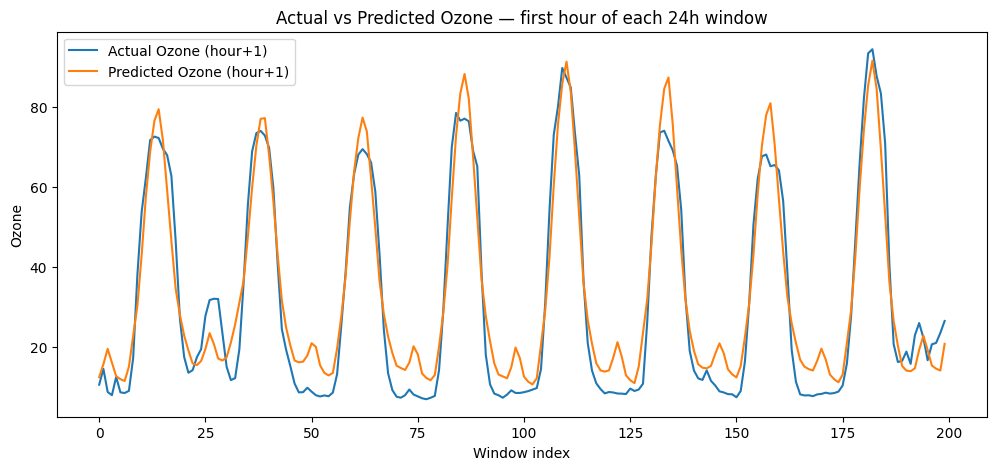

In [113]:
plt.figure(figsize=(12, 5))
plt.plot(y_test_actual_ozone[:200, 0], label='Actual Ozone (hour+1)')
plt.plot(y_pred_actual_ozone[:200, 0], label='Predicted Ozone (hour+1)')
plt.xlabel('Window index')
plt.ylabel('Ozone')
plt.title('Actual vs Predicted Ozone — first hour of each 24h window')
plt.legend()
plt.show()

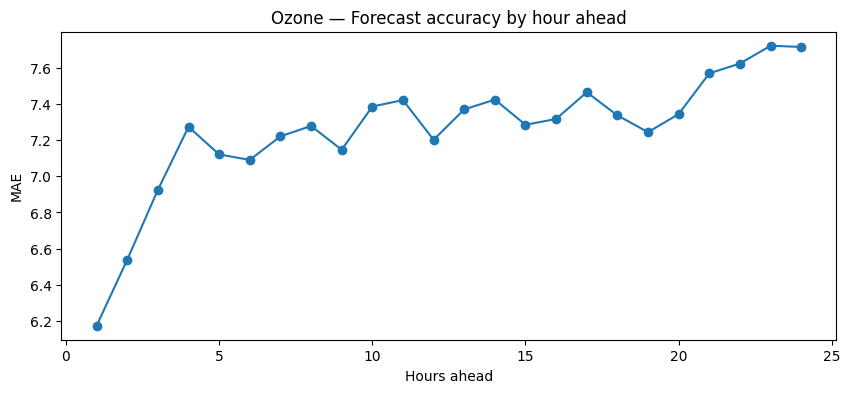

In [114]:
per_hour_mae_ozone = [mean_absolute_error(y_test_actual_ozone[:, h], y_pred_actual_ozone[:, h]) for h in range(24)]

plt.figure(figsize=(10, 4))
plt.plot(range(1, 25), per_hour_mae_ozone, marker='o')
plt.xlabel('Hours ahead')
plt.ylabel('MAE')
plt.title('Ozone — Forecast accuracy by hour ahead')
plt.show()

Text(0.5, 1.0, 'Ozone — R² by hour ahead')

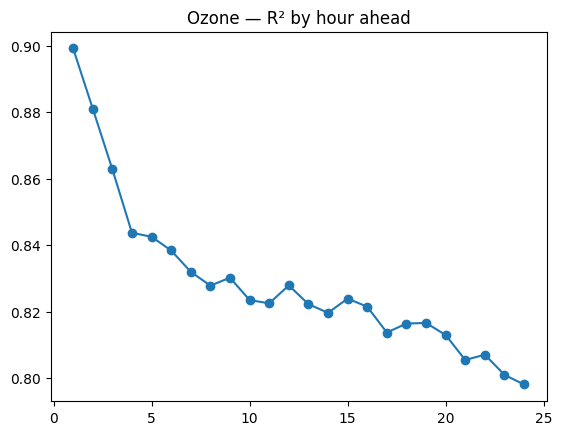

In [115]:
per_hour_r2_ozone = [r2_score(y_test_actual_ozone[:, h], y_pred_actual_ozone[:, h]) for h in range(24)]
plt.plot(range(1, 25), per_hour_r2_ozone, marker='o')
plt.title('Ozone — R² by hour ahead')